In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, r2_score, classification_report
from scipy.stats import wasserstein_distance, spearmanr
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from statsmodels.stats.outliers_influence import variance_inflation_factor
from skimage.metrics import structural_similarity as ssim
from matplotlib.colors import CenteredNorm
from torchview import draw_graph
from torchmetrics.functional.regression import r2_score as torch_r2_score
from torchmetrics.functional.image import structural_similarity_index_measure


In [2]:
target_res = 0.125
min_lon, min_lat, max_lon, max_lat =[-61.0, -47.5, -60.0, -44.875]
min_time, max_time = pd.to_datetime("2013-01-01"), pd.to_datetime("2025-12-31")

fishing_ds = xr.open_dataset(f"../data/processed/targets/cpue_{target_res}.nc").sel(FAOspp="HKP")
fishing = fishing_ds["cpue_index"]
fishing = fishing.fillna(0)

peso = fishing_ds["PesoTotal"]/1000
peso = np.log1p(peso)
peso = peso.fillna(0)

effort = xr.open_dataset(f"../data/processed/targets/esfuerzo_{target_res}.nc")
effort = effort["Horas"]/24
effort = effort.fillna(0)

mask_ds = xr.open_dataset(f"../data/processed/static/area_pesca_{target_res}.nc")
mask = mask_ds["mask"]
mask = mask.fillna(0)
mask = mask.broadcast_like(fishing)

temp_ds = xr.open_dataset("../data/processed/dynamic/to_surface.nc")
temp = temp_ds["to"]
temp = (temp - temp.mean()) / temp.std()
temp = temp.fillna(0)

temp_bottom_ds = xr.open_dataset("../data/processed/dynamic/temp_bottom.nc")
temp_bottom_ds = temp_bottom_ds.rename({"to": "to_b"})
temp_bottom = temp_bottom_ds["to_b"]
temp_bottom = (temp_bottom - temp_bottom.mean()) / temp_bottom.std()
temp_bottom = temp_bottom.fillna(0)

chl_ds = xr.open_dataset("../data/processed/dynamic/chl.nc")
chl = chl_ds["CHL"]
chl = (chl - chl.mean()) / chl.std()
chl = chl.fillna(0)

mixed_ds = xr.open_dataset("../data/processed/dynamic/mixed_layer.nc")
mixed = mixed_ds["mlotst"]
mixed = (mixed - mixed.mean()) / mixed.std()
mixed = mixed.fillna(0)

depth_ds = xr.open_dataset("../data/processed/static/depth.nc")
depth = depth_ds["depth"] 
depth = (depth - depth.mean()) / depth.std()
depth = depth.fillna(0)
depth = depth.broadcast_like(temp)

zo_ds = xr.open_dataset("../data/processed/dynamic/zo_surface.nc")
zo = zo_ds["zo"]
zo = (zo - zo.mean()) / zo.std()
zo = zo.fillna(0)

so_ds = xr.open_dataset("../data/processed/dynamic/so_surface.nc")
so = so_ds["so"]
so = (so - so.mean()) / so.std()
so = so.fillna(0)

ugo_ds = xr.open_dataset("../data/processed/dynamic/ugo_surface.nc")
ugo = ugo_ds["ugo"]
ugo = (ugo - ugo.mean()) / ugo.std()
ugo = ugo.fillna(0)

vgo_ds = xr.open_dataset("../data/processed/dynamic/vgo_surface.nc")
vgo = vgo_ds["vgo"]
vgo = (vgo - vgo.mean()) / vgo.std()
vgo = vgo.fillna(0)

pp = xr.open_dataset("../data/processed/dynamic/pp.nc")
pp = pp["PP"]
pp = (pp - pp.mean()) / pp.std()
pp = pp.fillna(0)

cdm = xr.open_dataset("../data/processed/dynamic/cdm.nc")
cdm = cdm["CDM"]
cdm = (cdm - cdm.mean()) / cdm.std()
cdm = cdm.fillna(0)

spm = xr.open_dataset("../data/processed/dynamic/spm.nc")
spm = spm["SPM"]
spm = (spm - spm.mean()) / spm.std()    
spm = spm.fillna(0)

zsd = xr.open_dataset("../data/processed/dynamic/zsd.nc")
zsd = zsd["ZSD"]
zsd = (zsd - zsd.mean()) / zsd.std()
zsd = zsd.fillna(0)


month = temp["time"].dt.month
month_sin = np.sin(2 * np.pi * month / 12)
month_cos = np.cos(2 * np.pi * month / 12)
month_sin = month_sin.broadcast_like(temp)
month_cos = month_cos.broadcast_like(temp)
month_sin.name = "month_sin"
month_cos.name = "month_cos"
month = month.broadcast_like(temp)

year = temp["time"].dt.year
year = (year - year.mean()) / year.std()
year = year.broadcast_like(temp)

lat = (temp["lat"] - temp["lat"].mean()) / temp["lat"].std()
lon = (temp["lon"] - temp["lon"].mean()) / temp["lon"].std()
lat = lat.broadcast_like(temp)
lon = lon.broadcast_like(temp)

temp, temp_bottom, chl, mixed, depth, month_sin, month_cos, lat, lon, zo, so, month, year, ugo, vgo, pp, cdm, spm, zsd = xr.align(
    temp, temp_bottom, chl, mixed, depth, month_sin, month_cos, lat, lon, zo, so, month, year, vgo, ugo, pp, cdm, spm, zsd, join="inner")

fishing, peso, effort, mask = xr.align(fishing, peso, effort, mask, join="inner")


#area de pesca y un poco alrededor
croppedT = lambda da: da.sel(
    lon=slice(min_lon-0.5, max_lon+0.5),
    lat=slice(min_lat-0.5, max_lat+0.5),
    time=slice(min_time, max_time)
)

# area global
cropped = lambda da: da.sel(
    lon=slice(min_lon-0, max_lon+2),
    lat=slice(min_lat-4, max_lat+1),
    time=slice(min_time, max_time)
)

fishing = croppedT(fishing)
effort = croppedT(effort)    
mask = croppedT(mask)
peso = croppedT(peso)

temp = cropped(temp)
temp_bottom = cropped(temp_bottom)
chl = cropped(chl)
mixed = cropped(mixed)
depth = cropped(depth)
zo = cropped(zo)
so = cropped(so)
month = cropped(month)
month_sin = cropped(month_sin)
month_cos = cropped(month_cos)
lat = cropped(lat)
lon = cropped(lon)
year = cropped(year)
ugo = cropped(ugo)
vgo = cropped(vgo)
pp = cropped(pp)
cdm = cropped(cdm)
spm = cropped(spm)
zsd = cropped(zsd)



In [3]:
y = fishing
y = y.transpose("time", "lat", "lon")

m = mask 
m = m.transpose("time", "lat", "lon")


vars_ = [temp, so, zo, temp_bottom,  
        ugo, vgo, mixed,
        cdm, #chl,  pp,
        month_sin, month_cos,
        # lat, lon,
        # depth,
        ]


vars_names = [v.name for v in vars_]
in_channels = len(vars_)
X = xr.concat(vars_, dim="channel")
X = X.transpose("time", "channel", "lat", "lon")
print(X.shape)
print(y.shape)
print(m.shape)

split_year = 2022

train_X = X.sel(time=slice(None, f"{split_year-1}-12-31"))
test_X  = X.sel(time=slice(f"{split_year}-01-01", None))

train_y = y.sel(time=slice(None, f"{split_year-1}-12-31"))
test_y  = y.sel(time=slice(f"{split_year}-01-01", None))

m_train = m.sel(time=slice(None, f"{split_year-1}-12-31"))
m_test  = m.sel(time=slice(f"{split_year}-01-01", None))


# -------- Check inflation factor --------
X_np = train_X.values  # (time, channel, lat, lon)
t, c, h, w = X_np.shape
X_flat = X_np.reshape(t, c, -1)       # (time, channel, pixels)
X_flat = X_flat.transpose(0, 2, 1)    # (time, pixels, channel)
X_flat = X_flat.reshape(-1, c)        # (samples, channel)
df = pd.DataFrame(X_flat, columns=vars_names)
vif_data = pd.DataFrame()
vif_data["feature"] = df.columns
vif_data["VIF"] = [variance_inflation_factor(df.values, i)for i in range(df.shape[1])]
print(vif_data.sort_values("VIF", ascending=False))

def create_windows(X, y, m, window=12):
    X_data = X.values   # (time, channels, H, W)
    y_data = y.values   # (time, H, W)
    m_data = m.values   # (time, H, W)

    X_seq, y_seq, m_seq= [], [], []

    for i in range(len(X_data) - window):
        X_seq.append(X_data[i:i+window]) #12 months
        y_seq.append(y_data[i+window]) #next month
        m_seq.append(m_data[i+window]) #next month
        

    return (
        torch.tensor(np.stack(X_seq), dtype=torch.float32),
        torch.tensor(np.stack(y_seq), dtype=torch.float32),
        torch.tensor(np.stack(m_seq), dtype=torch.float32),
    )

window = 12 #12 months

X_train, y_train, m_train = create_windows(train_X, train_y, m_train, window)
X_test, y_test, m_test = create_windows(test_X, test_y, m_test, window)

print(X_train.shape, X_test.shape)  # (N, T, C, H, W)
print(y_train.shape, y_test.shape)  # (N, H, W)
print(m_train.shape, m_test.shape)  # (N, H, W)
###### Data Loaders ######
batch_size = 24

train_loader = DataLoader(
    TensorDataset(X_train, y_train, m_train),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test, m_test),
    batch_size=batch_size,
    shuffle=False
)
########## residuals data loaders ##########

train_monthly_mean = train_y.groupby("time.month").mean("time")

train_y_res_da = train_y.groupby("time.month") - train_monthly_mean
test_y_res_da  = test_y.groupby("time.month") - train_monthly_mean

def create_residual_windows(y_res_da, window=12):
    y_res_data = y_res_da.values  # Shape: (time, H, W)
    y_res_seq = []
    
    for i in range(len(y_res_data) - window):
        y_res_seq.append(y_res_data[i + window])  # Target is the next month
        
    return torch.tensor(np.stack(y_res_seq), dtype=torch.float32)

y_res_train = create_residual_windows(train_y_res_da, window)
y_res_test  = create_residual_windows(test_y_res_da, window)


train_residual_loader = DataLoader(
    TensorDataset(X_train, y_res_train, m_train),
    batch_size=batch_size,
    shuffle=False
)

test_residual_loader = DataLoader(
    TensorDataset(X_test, y_res_test, m_test),
    batch_size=batch_size,
    shuffle=False
)


(156, 10, 62, 25)
(156, 30, 17)
(156, 30, 17)
     feature       VIF
3       to_b  6.029587
0         to  5.412759
2         zo  5.076337
1         so  4.464471
8  month_sin  3.858012
4        vgo  2.905017
6     mlotst  2.687445
9  month_cos  2.515059
5        ugo  2.264029
7        CDM  1.199297
torch.Size([96, 12, 10, 62, 25]) torch.Size([36, 12, 10, 62, 25])
torch.Size([96, 30, 17]) torch.Size([36, 30, 17])
torch.Size([96, 30, 17]) torch.Size([36, 30, 17])


In [4]:
# -------- UNet 3D blocks--------

# -------- Basic Conv Block --------
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.PReLU(out_ch),
            nn.Dropout3d(0.3),
            nn.Conv3d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.PReLU(out_ch),
            )

    def forward(self, x):
        return self.block(x)

# -------- Decoder Block --------
class DecoderBlock3D(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose3d(in_channels, out_channels, (1, 2, 2), stride=(1, 2, 2))
        self.conv_block = ConvBlock(out_channels + skip_channels, out_channels)
        
    def forward(self, x, skip):
        x = self.up(x)

        # Handle size mismatches
        x = F.interpolate(x, size=skip.shape[2:], mode='trilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)

        x = self.conv_block(x)
        return x

# -------- Temporal Aggregation Block --------
class TemporalAggregationBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.temporal_attn = nn.Sequential(
            nn.Conv3d(in_channels, in_channels, kernel_size=(3, 1, 1), padding=(1, 0, 0), groups=in_channels),
            nn.Sigmoid()
        )
        self.temporal_score = nn.Conv3d(in_channels, 1, kernel_size=1)
    
    def forward(self, x):
        # x shape: (B, C, T, H, W)
        attn = self.temporal_attn(x)
        feat = x * attn
        score = self.temporal_score(feat)
        weights = torch.softmax(score, dim=2) 
        feat = (feat * weights).sum(dim=2)    
        return feat

# -------- Global Attention Branch --------
class GlobalAttentionBranch(nn.Module):
    def __init__(self, channels, time_pooling=None):
        super().__init__()
        reduction = max(channels // 4, 8)
        self.branch = nn.Sequential(
            nn.AdaptiveAvgPool3d((time_pooling, 1, 1)),
            nn.Conv3d(channels, reduction, 1),
            nn.PReLU(reduction),
            nn.Conv3d(reduction, channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.branch(x)
    
# -------- Temporal Mixing Block --------
class TemporalMixBlock(nn.Module):
    def __init__(self, channels, window_size=5):
        super().__init__()
        
        # Enforce odd window size to ensure symmetric padding across time
        if window_size % 2 == 0:
            raise ValueError(f"window_size must be odd (3, 5, 7), got {window_size}")
        pad_t = window_size // 2

        self.mix = nn.Sequential(
            nn.Conv3d(channels, channels, kernel_size=(window_size, 1, 1), padding=(pad_t, 0, 0)),
            nn.BatchNorm3d(channels),
            nn.PReLU(channels)
        )

    def forward(self, x):
        return x + self.mix(x)

In [5]:
# -------- U-Net 3D temporal collapse after bottleneck --------
class UNet3D_2(nn.Module):
    def __init__(self, in_channels, out_hw, out_channels=1, base_ch=10):
        super().__init__()

        self.out_hw = out_hw  # (H, W)

        # -------- Encoder --------
        self.enc1 = ConvBlock(in_channels, base_ch)
        self.pool1 = nn.MaxPool3d((1, 2, 2))

        self.enc2 = ConvBlock(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d((1, 2, 2)) # (1, 2, 2) for no temporal downsampling

        # -------- Bottleneck --------
        self.bottleneck = ConvBlock(base_ch * 2, base_ch * 4)
        self.temp_mix = TemporalMixBlock(base_ch * 4, window_size=7)
        self.global_att = GlobalAttentionBranch(base_ch * 4)
        
        # -------- Decoder --------
        self.decoder2 = DecoderBlock3D(base_ch * 4, base_ch * 2, base_ch * 2)
        self.decoder1 = DecoderBlock3D(base_ch * 2, base_ch, base_ch)
    
        # -------- Temporal Aggregation --------
        self.temporal_agg = TemporalAggregationBlock(base_ch)

        # -------- Regression Head --------
        self.regressor = nn.Sequential(
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.PReLU(base_ch),
            nn.Conv2d(base_ch, out_channels, 1)
        )
        

    def forward(self, x, mask=None):
        # INPUT COMES AS: (B, T, C, H, W) Convert to:(B, C, T, H, W)
        x = x.permute(0, 2, 1, 3, 4)
        
        # -------- Encoder --------
        s1 = self.enc1(x)
        p1 = self.pool1(s1)

        s2 = self.enc2(p1)
        p2 = self.pool2(s2)

        # -------- Bottleneck --------
        b = self.bottleneck(p2)
        b = self.temp_mix(b)     
        b = b * self.global_att(b)

        # -------- Decoder --------
        d2 = self.decoder2(b, s2)
        d1 = self.decoder1(d2, s1)

        # -------- Temporal Aggregation --------
        final_2d = self.temporal_agg(d1)
        
        # -------- Regression Head --------
        final = self.regressor(final_2d)
        
        # interpolate to output shape      
        out = F.interpolate(final, size=self.out_hw, mode="bilinear", align_corners=False)

        if mask is not None:
            # Match out shape: (B, 1, H, W)
            out = out * mask.unsqueeze(1).float()
        return out

In [6]:
class SimpleCNN3D(nn.Module):

    def __init__(self, in_channels, out_hw, out_channels=1, base_ch=16):
        super().__init__()

        self.out_hw = out_hw

        # -------- Simple stacked CNN backbone --------
        self.features = nn.Sequential(
            nn.Conv3d(in_channels, base_ch, kernel_size=3, padding=1),
            nn.BatchNorm3d(base_ch),
            nn.GELU(),
            nn.Dropout3d(0.2),
            nn.Conv3d(base_ch, base_ch * 2, kernel_size=3, padding=1),
            nn.BatchNorm3d(base_ch * 2),
            nn.GELU(),
            nn.Conv3d(base_ch * 2, base_ch * 4, kernel_size=3, padding=1),
            nn.BatchNorm3d(base_ch * 4),
            nn.GELU(),
        )

        # -------- temporal modules --------
        self.temp_mix = TemporalMixBlock(base_ch * 4, window_size=7)

        self.global_att = GlobalAttentionBranch(base_ch * 4)

        self.temporal_agg = TemporalAggregationBlock(base_ch * 4)

        # -------- 2D regression head --------
        self.regressor = nn.Sequential(
            nn.Conv2d(base_ch * 4, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.GELU(),

            nn.Conv2d(base_ch * 2, out_channels, 1)
        )

    def forward(self, x, mask=None):

        # Input: (B, T, C, H, W)
        # Convert to: (B, C, T, H, W)
        x = x.permute(0, 2, 1, 3, 4)

        # -------- Simple CNN backbone --------
        x = self.features(x)

        # -------- Attention --------
        x = self.temp_mix(x)

        x = x * self.global_att(x)

        # Collapse temporal dimension
        x = self.temporal_agg(x)

        # -------- Regression --------
        x = self.regressor(x)

        # -------- Resize to desired output --------
        out = F.interpolate(
            x,
            size=self.out_hw,
            mode="bilinear",
            align_corners=False
        )

        return out

In [7]:
# -------- SSIM loss functions --------
def huber_SSIM_loss(pred, target, mask, ssim_weight=1.0, huber_delta=1.0, window_size=7):
    """
    pred:   (B, 1, H, W)
    target: (B, H, W)
    mask:   (B, H, W)
    """
    # Ensure window_size is odd to preserve spatial dimensions
    if window_size % 2 == 0:
        window_size += 1
        
    # Ensure target and mask match pred shape: (B, 1, H, W)
    target = target.unsqueeze(1)
    mask = mask.unsqueeze(1).float()
    
    # Calculate valid pixels to average the loss correctly
    valid_pixels = mask.sum().clamp(min=1e-8)
    
    # -------- 1. Huber Loss --------
    huber_map = F.huber_loss(pred, target, delta=huber_delta, reduction='none')
    huber = (huber_map * mask).sum() / valid_pixels
    
    # -------- 2. Differentiable SSIM Loss --------
    data_range = target.max() - target.min() + 1e-8
    C1 = (0.01 * data_range) ** 2
    C2 = (0.03 * data_range) ** 2

    # Using avg_pool2d as a fast, uniform sliding window
    pad = window_size // 2
    
    mu_pred = F.avg_pool2d(pred, window_size, stride=1, padding=pad)
    mu_target = F.avg_pool2d(target, window_size, stride=1, padding=pad)

    sigma_pred_sq = F.avg_pool2d(pred**2, window_size, stride=1, padding=pad) - mu_pred**2
    sigma_target_sq = F.avg_pool2d(target**2, window_size, stride=1, padding=pad) - mu_target**2
    sigma_pt = F.avg_pool2d(pred * target, window_size, stride=1, padding=pad) - mu_pred * mu_target

    # SSIM Formula
    numerator = (2 * mu_pred * mu_target + C1) * (2 * sigma_pt + C2)
    denominator = (mu_pred**2 + mu_target**2 + C1) * (sigma_pred_sq + sigma_target_sq + C2)
    
    ssim_map = numerator / denominator
    
    # Apply mask to SSIM map
    ssim_loss_val = 1.0 - (ssim_map * mask).sum() / valid_pixels
    
    # -------- Combine -------- 
    return huber + (ssim_weight * ssim_loss_val)


def MSE_SSIM_loss(pred, target, mask, ssim_weight=0.5, window_size=7):
    """
    pred:   (B, 1, H, W)
    target: (B, H, W)
    mask:   (B, H, W)
    """
    # Ensure window_size is odd to preserve spatial dimensions
    if window_size % 2 == 0:
        window_size += 1
        
    # Ensure target and mask match pred shape: (B, 1, H, W)
    target = target.unsqueeze(1)
    mask = mask.unsqueeze(1).float()
    
    # Calculate valid pixels to average the loss correctly
    valid_pixels = mask.sum().clamp(min=1e-8)
    
    # -------- 1. MSE Loss --------
    mse_map = F.mse_loss(pred, target, reduction='none')
    mse = (mse_map * mask).sum() / valid_pixels
    
    # -------- 2. Differentiable SSIM Loss --------
    data_range = target.max() - target.min() + 1e-8
    C1 = (0.01 * data_range) ** 2
    C2 = (0.03 * data_range) ** 2

    # Using avg_pool2d as a fast, uniform sliding window
    pad = window_size // 2
    
    mu_pred = F.avg_pool2d(pred, window_size, stride=1, padding=pad)
    mu_target = F.avg_pool2d(target, window_size, stride=1, padding=pad)

    sigma_pred_sq = F.avg_pool2d(pred**2, window_size, stride=1, padding=pad) - mu_pred**2
    sigma_target_sq = F.avg_pool2d(target**2, window_size, stride=1, padding=pad) - mu_target**2
    sigma_pt = F.avg_pool2d(pred * target, window_size, stride=1, padding=pad) - mu_pred * mu_target

    # SSIM Formula
    numerator = (2 * mu_pred * mu_target + C1) * (2 * sigma_pt + C2)
    denominator = (mu_pred**2 + mu_target**2 + C1) * (sigma_pred_sq + sigma_target_sq + C2)
    
    ssim_map = numerator / denominator
    
    # Apply mask to SSIM map
    ssim_loss_val = 1.0 - (ssim_map * mask).sum() / valid_pixels
    
    # -------- Combine --------
    return mse + (ssim_weight * ssim_loss_val)

In [8]:
#-------- Custom Geospatial Loss Module --------
class GeospatialLoss(nn.Module):
    def __init__(self, ssim_weight=1.0, window_size=7, huber_delta=1.0):
        super().__init__()
        self.ssim_weight = ssim_weight
        self.window_size = window_size
        self.huber_delta = huber_delta
        
        # Create a uniform 2D window for spatial context tracking
        self.register_buffer(
            "window", 
            torch.ones(1, 1, window_size, window_size) / (window_size ** 2)
        )

    def forward(self, pred, target, mask):
        """
        pred:   (B, 1, H, W)
        target: (B, H, W)
        mask:   (B, H, W)
        """
        # Ensure target and mask match prediction dimensions
        target = target.unsqueeze(1) 
        mask = mask.unsqueeze(1).float() # (B, 1, H, W)
        
        # 1. Huber Loss: Computed pixel-wise, then masked and averaged
        base_loss = F.huber_loss(pred, target, reduction='none', delta=self.huber_delta)
        masked_base_loss = (base_loss * mask).sum() / (mask.sum() + 1e-8)
        
        # 2. Fully Differentiable Masked SSIM
        ssim_loss = self._differentiable_ssim(pred, target, mask)
        
        return masked_base_loss + (self.ssim_weight * ssim_loss)

    def _differentiable_ssim(self, pred, target, mask):
        # Capture target spatial dimensions to prevent padding overshoots
        _, _, H, W = pred.shape
        
        # Dynamically calculate the data range per image in the batch
        max_val = target.amax(dim=(2, 3), keepdim=True)
        min_val = target.amin(dim=(2, 3), keepdim=True)
        data_range = max_val - min_val + 1e-8
        
        C1 = (0.01 * data_range) ** 2
        C2 = (0.03 * data_range) ** 2

        pad = self.window_size // 2

        # Calculate means (with explicit slicing to guarantee matching shapes)
        mu1 = F.conv2d(pred, self.window, padding=pad)[:, :, :H, :W]
        mu2 = F.conv2d(target, self.window, padding=pad)[:, :, :H, :W]

        mu1_sq, mu2_sq, mu1_mu2 = mu1 ** 2, mu2 ** 2, mu1 * mu2

        # Calculate variances (with explicit slicing to guarantee matching shapes)
        sigma1_sq = F.conv2d(pred * pred, self.window, padding=pad)[:, :, :H, :W] - mu1_sq
        sigma2_sq = F.conv2d(target * target, self.window, padding=pad)[:, :, :H, :W] - mu2_sq
        sigma12 = F.conv2d(pred * target, self.window, padding=pad)[:, :, :H, :W] - mu1_mu2

        # SSIM map calculation
        ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
                   ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
        
        # Apply mask to SSIM map safely
        masked_ssim = (ssim_map * mask).sum() / (mask.sum() + 1e-8)
        
        # Minimize loss -> return 1 - SSIM
        return 1.0 - masked_ssim

Saved
Epoch 1/300 | Loss: 3.8852 | Train R2: -0.535 | R2: -0.743 | Best Score: -0.365 | Best R2: -0.743 | SSIM: 0.013 | BestSSIM: 0.013 | Bias: -2.246 | Corr: 0.250
Saved
Epoch 2/300 | Loss: 3.1876 | Train R2: -0.105 | R2: -0.703 | Best Score: -0.337 | Best R2: -0.703 | SSIM: 0.028 | BestSSIM: 0.028 | Bias: -2.194 | Corr: 0.478
Saved
Epoch 3/300 | Loss: 2.7751 | Train R2: 0.098 | R2: -0.573 | Best Score: -0.269 | Best R2: -0.573 | SSIM: 0.035 | BestSSIM: 0.035 | Bias: -2.055 | Corr: 0.589
Saved
Epoch 4/300 | Loss: 2.6669 | Train R2: 0.125 | R2: -0.171 | Best Score: -0.019 | Best R2: -0.171 | SSIM: 0.132 | BestSSIM: 0.132 | Bias: -1.515 | Corr: 0.538
Saved
Epoch 5/300 | Loss: 2.5910 | Train R2: 0.156 | R2: 0.208 | Best Score: 0.258 | Best R2: 0.208 | SSIM: 0.308 | BestSSIM: 0.308 | Bias: -0.929 | Corr: 0.623
Saved
Epoch 6/300 | Loss: 2.3554 | Train R2: 0.269 | R2: 0.221 | Best Score: 0.282 | Best R2: 0.221 | SSIM: 0.343 | BestSSIM: 0.343 | Bias: -0.871 | Corr: 0.596
Saved
Epoch 7/300 | 

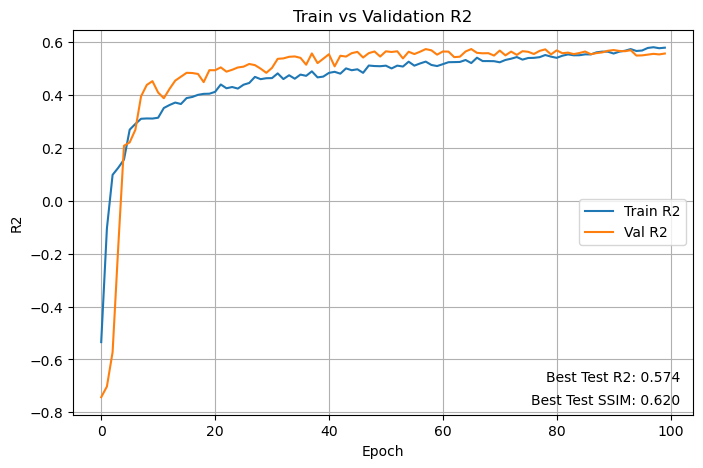

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

out_hw = y_train.shape[1:]

model = UNet3D_2(in_channels=in_channels, out_hw=out_hw, 
               base_ch=12
               ).to(device)
criterion = GeospatialLoss(ssim_weight=1.0, huber_delta=2.0).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=10e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=20)

best_test_r2 = -float("inf")
best_test_ssim = -float("inf")
best_combined_score = float("-inf")
best_model_path = "./modelos/modelo.pth"

patience = 30
epochs = 300
counter = 0

train_r2_history = []
val_r2_history = []
test_ssim_history = [] 

# -------- Training loop --------
for epoch in range(epochs):

    # -------- Training --------
    model.train()
    total_loss = 0
    train_r2s = []

    for x, y, m in train_loader:
    # for x, y, m in train_residual_loader:

        x = x.to(device)      # (B,T,C,H,W)
        y = y.to(device)      # (B,H,W)
        m = m.to(device)      # (B,H,W)

        optimizer.zero_grad()
        pred = model(x)       # (B,1,H,W)

        # ----- Loss -----
        loss = criterion(pred, y, m)
        # loss = MSE_SSIM_loss(pred, y, m, ssim_weight=1.0)
        # loss = huber_SSIM_loss(pred, y, m, ssim_weight=0.5, huber_delta=0.5)

        loss.backward()
        optimizer.step()

        total_loss += loss.detach()
        
        # ----- Metrics -----
        pred_np = pred.detach().cpu().squeeze(1).numpy()   # (B,H,W)
        y_np = y.detach().cpu().numpy()                    # (B,H,W)
        m_np = m.detach().cpu().numpy()                    # (B,H,W)
        
        # Flatten and filter by mask
        y_true = y_np.reshape(-1)
        y_pred = pred_np.reshape(-1)
        m_flat = m_np.reshape(-1)
        
        valid_idx = m_flat > 0.5 
        y_true_valid = y_true[valid_idx]
        y_pred_valid = y_pred[valid_idx]

        if len(y_true_valid) > 1:
            train_r2s.append(r2_score(y_true_valid, y_pred_valid))

    train_r2 = np.mean(train_r2s) if len(train_r2s) > 0 else float("nan")

    # -------- Validation --------
    model.eval()

    # Lists to accumulate flat masked data for global regression metrics
    all_y_true_valid = []
    all_y_pred_valid = []
    
    # SSIM is an image-level metric, so we still accumulate it per-image
    test_ssims = []

    with torch.no_grad():
        for x, y, m in test_loader:
        # for x, y, m in test_residual_loader:
            x = x.to(device)
            y = y.to(device)
            m = m.to(device)

            pred = model(x)

            # ----- Convert to numpy -----
            pred_np = pred.detach().cpu().squeeze(1).numpy()
            y_np = y.detach().cpu().numpy()
            m_np = m.detach().cpu().numpy()

            # ----- 1. Accumulate Global Data for Regression Metrics -----
            y_true_flat = y_np.reshape(-1)
            y_pred_flat = pred_np.reshape(-1)
            m_flat = m_np.reshape(-1)
            
            valid_idx = m_flat > 0.5
            
            # Append only the valid pixels to our global lists
            all_y_true_valid.append(y_true_flat[valid_idx])
            all_y_pred_valid.append(y_pred_flat[valid_idx])

            # ----- 2. Masked SSIM Calculation (Per Image) -----
            # Reshape is technically redundant if y_np is already 3D, but keeping your logic safe
            y_np_spatial = y_np.reshape(pred_np.shape)
            m_np_spatial = m_np.reshape(pred_np.shape)
            
            for i in range(len(pred_np)):
                # Calculate dynamic range for this specific image
                d_range = max(y_np_spatial[i].max() - y_np_spatial[i].min(), 1e-5)
                min_dim = min(y_np_spatial[i].shape)
                
                if min_dim < 7:
                    win_size = min_dim if min_dim % 2 != 0 else min_dim - 1
                    if win_size < 3: win_size = 3
                    _, ssim_img = ssim(y_np_spatial[i], pred_np[i], data_range=d_range, win_size=win_size, full=True)
                else:
                    _, ssim_img = ssim(y_np_spatial[i], pred_np[i], data_range=d_range, full=True)
                
                # Extract the spatial mask for this image and calculate mean SSIM only where valid
                valid_mask = m_np_spatial[i] > 0.5
                if valid_mask.sum() > 0:
                    masked_score = ssim_img[valid_mask].mean()
                    test_ssims.append(masked_score)

    # =====================================================
    # ----- Final Global Metric Computation -----
    # =====================================================
    
    # Concatenate all batches into single 1D arrays
    if len(all_y_true_valid) > 0:
        global_y_true = np.concatenate(all_y_true_valid)
        global_y_pred = np.concatenate(all_y_pred_valid)
    else:
        global_y_true, global_y_pred = np.array([]), np.array([])

    # Compute global regression metrics
    if len(global_y_true) > 1:
        test_r2 = r2_score(global_y_true, global_y_pred)
        test_mae = mean_absolute_error(global_y_true, global_y_pred)
        test_bias = np.mean(global_y_pred - global_y_true)
        
        # Protect pearson from perfectly flat arrays
        if np.std(global_y_true) > 0 and np.std(global_y_pred) > 0:
            test_corr = pearsonr(global_y_true, global_y_pred)[0]
        else:
            test_corr = float("nan")
    else:
        test_r2 = float("nan")
        test_mae = float("nan")
        test_bias = float("nan")
        test_corr = float("nan")

    # Average the valid image-level SSIMs
    test_ssim = np.mean(test_ssims) if len(test_ssims) > 0 else float("nan")

    # -------- Early stopping --------
    improved = False
    scheduler.step(test_r2)
    if test_r2 > best_test_r2:
        best_test_r2 = test_r2
        improved = True
    if test_ssim > best_test_ssim:
        best_test_ssim = test_ssim
        improved = True
    
    combined_score = 0.5*test_r2 + 0.5*test_ssim
    if combined_score > best_combined_score:
        best_combined_score = combined_score
        improved = True
        torch.save(model.state_dict(), best_model_path)
        print("Saved")
            
    if improved:
        counter = 0
    else:
        counter += 1
        
    if counter >= patience:
        print("Early stopping")
        break

    # -------- Logging --------
    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {total_loss/len(train_loader):.4f} | "
        f"Train R2: {train_r2:.3f} | "
        f"R2: {test_r2:.3f} | "
        f"Best Score: {best_combined_score:.3f} | "
        f"Best R2: {best_test_r2:.3f} | "
        f"SSIM: {test_ssim:.3f} | "
        f"BestSSIM: {best_test_ssim:.3f} | "
        f"Bias: {test_bias:.3f} | "
        f"Corr: {test_corr:.3f}"
    )

    train_r2_history.append(train_r2)
    val_r2_history.append(test_r2)

# -------- Plot --------
plt.figure(figsize=(8,5))
plt.plot(train_r2_history, label="Train R2")
plt.plot(val_r2_history, label="Val R2")
plt.xlabel("Epoch")
plt.ylabel("R2")
plt.title("Train vs Validation R2")
plt.annotate(f"Best Test R2: {best_test_r2:.3f}", xy=(0.98, 0.08), xycoords='axes fraction', ha='right', va='bottom')
plt.annotate(f"Best Test SSIM: {best_test_ssim:.3f}", xy=(0.98, 0.02), xycoords='axes fraction', ha='right', va='bottom')
plt.legend()
plt.grid(True)
plt.show()



In [10]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()
all_preds = []
all_targets = []
all_masks = []  

with torch.no_grad():
    for x, y, m in test_loader:
        x = x.to(device)
        
        # Output shape: (B, H, W)
        pred = model(x).squeeze(1) 

        # Keep them raw; do not multiply by m here
        all_preds.append(pred.cpu().numpy())
        all_targets.append(y.cpu().numpy())
        all_masks.append(m.cpu().numpy())

# Concatenate along the batch dimension (N, H, W)
all_preds = np.concatenate(all_preds, axis=0)     
all_targets = np.concatenate(all_targets, axis=0) 
all_masks = np.concatenate(all_masks, axis=0)

mean_pred = all_preds.mean(axis=0)     # (H, W)
mean_true = all_targets.mean(axis=0)   # (H, W)

In [11]:
def compute_metrics_dl(y_true, y_pred, mask_spatial):
    mask_bool = mask_spatial.astype(bool)


    # =====================================================
    # 1. FLATTEN FOR METRICS
    # =====================================================
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    if mask_bool.ndim == 2:
        mask_flat = np.broadcast_to(mask_bool, y_true.shape).flatten()
    else:
        mask_flat = mask_bool.flatten()

    y_test_masked = y_true_flat[mask_flat]
    y_pred_masked = y_pred_flat[mask_flat]

    # =====================================================
    # 2. REGRESSION METRICS
    # =====================================================
    rmse = np.sqrt(mean_squared_error(y_test_masked, y_pred_masked))
    mae = mean_absolute_error(y_test_masked, y_pred_masked)
    r2 = r2_score(y_test_masked, y_pred_masked)
    pearson_corr = pearsonr(y_test_masked, y_pred_masked)[0]
    mbe = np.mean(y_pred_masked - y_test_masked)
    data_range_flat = np.max(y_test_masked) - np.min(y_test_masked)
    nrmse = rmse / data_range_flat

    w_dist = wasserstein_distance(y_test_masked, y_pred_masked)
    spearman_corr, p_val = spearmanr(y_test_masked, y_pred_masked)


    print("RMSE:", f"{rmse:.4f}")
    print(f"Normalized RMSE: {nrmse:.4f} ({nrmse*100:.2f}%)")
    print("MAE:", f"{mae:.4f}")
    print("R2:", f"{r2:.4f}")
    print("Pearson R:", f"{pearson_corr:.4f}")
    print("MBE:", f"{mbe:.4f}")
    print(f"Wasserstein Distance: {w_dist:.4f}")
    print(f"Spearman Rank Correlation: {spearman_corr:.2f}")


    # =====================================================
    # HOTSPOT Hit Rate (Top-K Overlap)
    # =====================================================
    percentile = 80
    hotspot_threshold_true = np.percentile(y_test_masked, percentile)
    hotspot_threshold_pred = np.percentile(y_pred_masked, percentile)

    # Create boolean masks for the top 20%
    actual_hotspots = (y_test_masked >= hotspot_threshold_true)
    pred_hotspots = (y_pred_masked >= hotspot_threshold_pred)

    # Count how many points are in the true top 20%
    total_actual_hotspots = np.sum(actual_hotspots)

    # Count how many points are in BOTH the true top 20% AND predicted top 20%
    shared_hotspots = np.sum(actual_hotspots & pred_hotspots)

    # Calculate the Hit Rate percentage
    hit_rate = shared_hotspots / total_actual_hotspots
    hit_rate_percent = hit_rate * 100

    print(f"\n--- Total hotspot Hit Rate (Top {100-percentile}% Overlap) ---")
    print(f"Total True Hotspots             : {total_actual_hotspots}")
    print(f"Correctly Predicted Hotspots    : {shared_hotspots}")
    print(f"Hit Rate                        : {hit_rate_percent:.4f}%")
    print(f"-------------------------------------------------\n")

    # =====================================================
    # YEARLY HOTSPOT Hit Rate (Top-K Overlap)
    # =====================================================
    percentile = 80
    months_per_year = 12
    num_months = y_true.shape[0]
    
    # Rebuild 3D shape to iterate over time safely
    H_out, W_out = y_true.shape[1], y_true.shape[2]
    y_pred3D_temp = y_pred_flat.reshape(-1, H_out, W_out)
    
    print(f"\n------- Yearly Hotspot Hit Rate (Top {100-percentile}% Overlap) ------")
    
    for year_idx, start_idx in enumerate(range(0, num_months, months_per_year)):
        end_idx = min(start_idx + months_per_year, num_months)
        
        y_true_year_list = []
        y_pred_year_list = []
        
        # Accumulate all valid pixels for the months belonging to this specific year
        for i in range(start_idx, end_idx):
            current_mask = mask_spatial[i] if mask_spatial.ndim == 3 else mask_spatial
            current_mask = current_mask.astype(bool)
            
            y_true_year_list.append(y_true[i][current_mask])
            y_pred_year_list.append(y_pred3D_temp[i][current_mask])
            
        # Concatenate valid pixels across the entire year chunk
        y_true_year = np.concatenate(y_true_year_list)
        y_pred_year = np.concatenate(y_pred_year_list)
        
        if len(y_true_year) == 0:
            continue
            
        # Calculate the 80th percentile threshold pooled for THIS specific year
        thresh_true_year = np.percentile(y_true_year, percentile)
        thresh_pred_year = np.percentile(y_pred_year, percentile)
        
        # Create boolean masks for the top 20%
        actual_hotspots_year = (y_true_year >= thresh_true_year)
        pred_hotspots_year = (y_pred_year >= thresh_pred_year)
        
        # Count overlaps
        total_actual_year = np.sum(actual_hotspots_year)
        shared_year = np.sum(actual_hotspots_year & pred_hotspots_year)
        
        # Calculate yearly hit rate
        year_hit_rate = (shared_year / total_actual_year) * 100 if total_actual_year > 0 else 0
        calendar_year = split_year + year_idx 
        
        print(f"Year {calendar_year} (Indices {start_idx} to {end_idx-1}):")
        print(f"  Total True Hotspots     : {total_actual_year}")
        print(f"  Correctly Predicted    : {shared_year}")
        print(f"  Hit Rate               : {year_hit_rate:.4f}%")
        
    print(f"-------------------------------------------------\n")
    
    # =====================================================
    # MONTHLY HOTSPOT Hit Rate (Top-K Overlap)
    # =====================================================
    percentile = 80
    
    # Rebuild 3D shape to iterate over time (months)
    H_out, W_out = y_true.shape[1], y_true.shape[2]
    y_pred3D_temp = y_pred_flat.reshape(-1, H_out, W_out)
    
    total_actual_hotspots_all = 0
    shared_hotspots_all = 0
    monthly_hit_rates = []
    
    # Iterate through each month (time step)
    for i in range(y_true.shape[0]):
        
        # Handle the spatial mask safely (whether it is 2D or 3D)
        current_mask = mask_spatial[i] if mask_spatial.ndim == 3 else mask_spatial
        current_mask = current_mask.astype(bool)
        # Extract valid pixels strictly for this month
        y_true_month = y_true[i][current_mask]
        y_pred_month = y_pred3D_temp[i][current_mask]
        
        # Skip if mask leaves no valid pixels for this month
        if len(y_true_month) == 0:
            continue
            
        # Calculate the 80th percentile threshold for THIS specific month
        thresh_true = np.percentile(y_true_month, percentile)
        thresh_pred = np.percentile(y_pred_month, percentile)
        
        # Create boolean masks for the top 20%
        actual_hotspots_month = (y_true_month >= thresh_true)
        pred_hotspots_month = (y_pred_month >= thresh_pred)
        
        # Count overlaps
        total_actual = np.sum(actual_hotspots_month)
        shared = np.sum(actual_hotspots_month & pred_hotspots_month)
        
        # Keep running totals for the aggregate score
        total_actual_hotspots_all += total_actual
        shared_hotspots_all += shared
        
        # Calculate hit rate strictly for this month
        if total_actual > 0:
            monthly_hit_rates.append((shared / total_actual) * 100)

    # Calculate final aggregate metrics across all months
    mean_monthly_hit_rate = np.mean(monthly_hit_rates)
    aggregate_hit_rate = (shared_hotspots_all / total_actual_hotspots_all) * 100 if total_actual_hotspots_all > 0 else 0
    print(f"\n------- Monthly Hotspot Hit Rate (Top {100-percentile}% Overlap) ------")
    print(f"Total True Hotspots (All Months)    : {total_actual_hotspots_all}")
    print(f"Correctly Predicted (All Months)    : {shared_hotspots_all}")
    print(f"Mean Monthly Hit Rate               : {mean_monthly_hit_rate:.3f}%")
    print(f"Aggregate Hit Rate                  : {aggregate_hit_rate:.3f}%")
    print(f"-------------------------------------------------\n")

    # =====================================================
    # 4. MASKED SSIM
    # =====================================================
    data_range = y_true[mask_bool].max() - y_true[mask_bool].min()
    ssim_scores = []

    for i in range(y_true.shape[0]):
        _, ssim_map = ssim(
            y_true[i], y_pred[i],
            data_range=data_range, win_size=5, full=True
        )
        current_mask = mask_bool if mask_bool.ndim == 2 else mask_bool[i]
        valid_ssim_pixels = ssim_map[current_mask]

        if len(valid_ssim_pixels) > 0:
            ssim_scores.append(np.mean(valid_ssim_pixels))

    mean_ssim = np.mean(ssim_scores)
    print(f"Mean Masked SSIM: {mean_ssim:.4f}\n")

    # =====================================================
    # 5. PLOTTING (MASKED)
    # =====================================================
    if mask_bool.ndim == 3:
        mean_mask_2d = mask_bool[0] 
    else:
        mean_mask_2d = mask_bool

    # Compute means over time axis
    y_pred_mean = np.mean(y_pred, axis=0)
    y_true_mean = np.mean(y_true, axis=0)
    error = y_pred_mean - y_true_mean

    # Apply spatial mask by setting invalid regions to NaN
    y_true_mean_masked = np.where(mean_mask_2d, y_true_mean, np.nan)
    y_pred_mean_masked = np.where(mean_mask_2d, y_pred_mean, np.nan)
    error_masked = np.where(mean_mask_2d, error, np.nan)
    
    y_true_plot1 =  np.nan_to_num(y_true_mean_masked, nan=0)
    y_pred_plot1 = np.nan_to_num(y_pred_mean_masked, nan=0)

    plt.figure(figsize=(12, 4))

    ax1 = plt.subplot(1, 3, 1)
    plt.title("Mean Test Truth")
    plt.imshow(y_true_plot1, cmap='viridis')
    plt.colorbar()
    ax1.invert_yaxis()

    ax2 = plt.subplot(1, 3, 2)
    plt.title("Mean Test Prediction")
    plt.imshow(y_pred_plot1, cmap='viridis')
    plt.colorbar()
    ax2.invert_yaxis()

    ax3 = plt.subplot(1, 3, 3)
    plt.title("Mean Error (Pred - True)")
    # Using symmetric limits around zero so 'coolwarm' centers beautifully
    vmax = np.nanmax(np.abs(error_masked)) if not np.isnan(error_masked).all() else 1.0
    plt.imshow(error_masked, cmap='coolwarm', norm=CenteredNorm())
    plt.colorbar()
    ax3.invert_yaxis()

    plt.tight_layout()
    plt.show()

    # =====================================================
    # TIME SERIES COMPARISON (MASKED)
    # =====================================================
    y_true_time = []
    y_pred_time = []

    for i in range(y_true.shape[0]):
        current_mask = mask_bool if mask_bool.ndim == 2 else mask_bool[i]
        
        y_true_time.append(np.mean(y_true[i][current_mask]))
        y_pred_time.append(np.mean(y_pred[i][current_mask]))

    y_true_plot2 = np.array(y_true_time)
    y_pred_plot2 = np.array(y_pred_time)
    r2_plot2 = r2_score(y_true_plot2, y_pred_plot2)

    plt.figure(figsize=(12, 4))
    plt.plot(y_true_plot2, label="True", marker='o', markersize=3)
    plt.plot(y_pred_plot2, label="Predicted", marker='x', markersize=3)
    
    plt.annotate(f"Time Series R2: {r2_plot2:.3f}", xy=(0.98, 0.02), xycoords='axes fraction', ha='right', va='bottom')
    plt.xlabel("Time (Months)")
    plt.ylabel("Mean Value")
    plt.title("Time Series Comparison")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

RMSE: 1.7007
Normalized RMSE: 0.1708 (17.08%)
MAE: 1.1028
R2: 0.5734
Pearson R: 0.7581
MBE: -0.0904
Wasserstein Distance: 0.6906
Spearman Rank Correlation: 0.72

--- Total hotspot Hit Rate (Top 20% Overlap) ---
Total True Hotspots             : 900
Correctly Predicted Hotspots    : 511
Hit Rate                        : 56.7778%
-------------------------------------------------


------- Yearly Hotspot Hit Rate (Top 20% Overlap) ------
Year 2022 (Indices 0 to 11):
  Total True Hotspots     : 300
  Correctly Predicted    : 195
  Hit Rate               : 65.0000%
Year 2023 (Indices 12 to 23):
  Total True Hotspots     : 300
  Correctly Predicted    : 160
  Hit Rate               : 53.3333%
Year 2024 (Indices 24 to 35):
  Total True Hotspots     : 300
  Correctly Predicted    : 151
  Hit Rate               : 50.3333%
-------------------------------------------------


------- Monthly Hotspot Hit Rate (Top 20% Overlap) ------
Total True Hotspots (All Months)    : 1482
Correctly Predicted (A

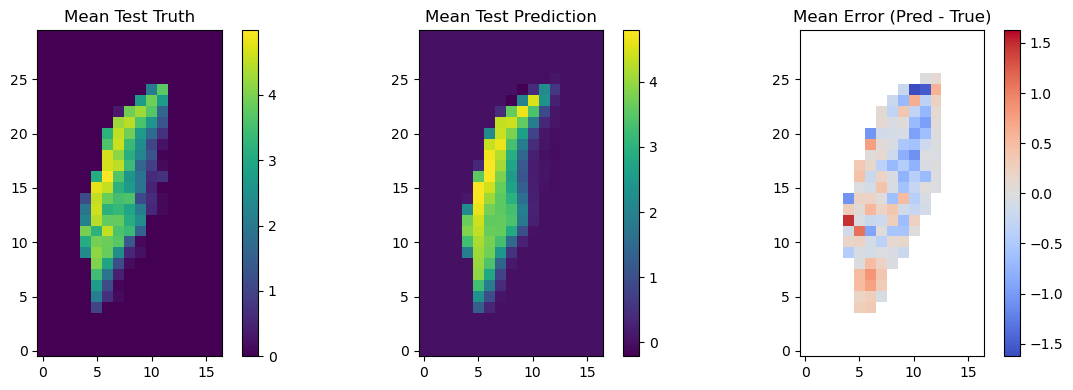

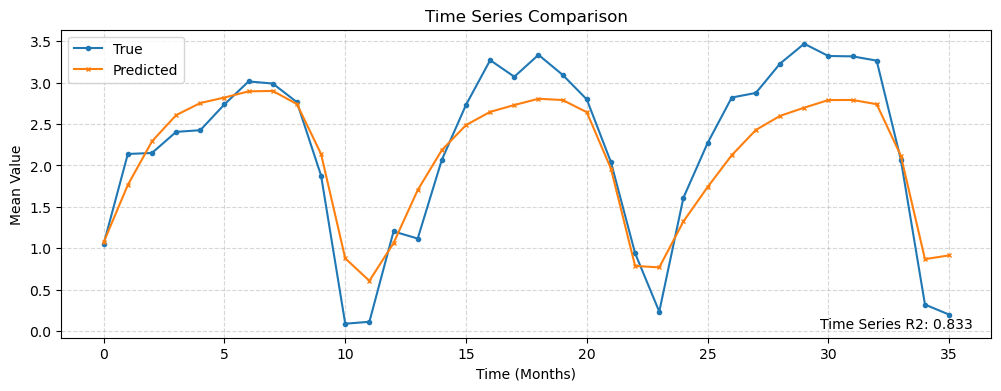

In [12]:
compute_metrics_dl(
    y_true=all_targets, 
    y_pred=all_preds, 
    mask_spatial=all_masks
)


In [13]:
graph_model = UNet3D_2(
    in_channels=X_test.shape[2],
    out_hw=(y_test.shape[1], y_test.shape[2]),
    base_ch=8
)

graph = draw_graph(
    graph_model,
    input_size=(1, X_test.shape[1], X_test.shape[2], X_test.shape[3], X_test.shape[4]),
    expand_nested=True,
    roll=True,
    )

graph.visual_graph.graph_attr.update(dpi="200")


graph.visual_graph.render("./modelos/modelo", format="png")



couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.

'modelos\\modelo.png'

In [14]:
def evaluate_with_zeroed_channel(model, loader, channel_to_zero, device):
    model.eval()
    
    total_loss = 0.0
    total_r2 = 0.0
    total_ssim = 0.0
    total_samples = 0

    with torch.no_grad():
        for x, y, m in loader:
            x = x.clone().to(device)
            y = y.to(device)
            m = m.to(device)
            
            batch_size = x.size(0)

            if isinstance(channel_to_zero, int):
                x[:, :, channel_to_zero, :, :] = 0
            if channel_to_zero ==  "all":
                x[:, :, :, :, :] = 0

            pred = model(x)
            loss = criterion(pred, y, m)
            pred_matched = pred.view_as(y)
            
            # --- GPU R2 Score (Mask-Aware) ---
            m_bool = m > 0.5
            y_true_flat = y[m_bool]
            y_pred_flat = pred_matched[m_bool]

            if y_true_flat.numel() > 1 and torch.var(y_true_flat) > 0:
                r2 = torch_r2_score(y_pred_flat, y_true_flat)
            else:
                r2 = torch.tensor(0.0, device=device)

            H, W = y.shape[-2], y.shape[-1]
            y_slices = y.reshape(-1, 1, H, W)
            pred_slices = pred.reshape(-1, 1, H, W)
            
            # Dynamic data range calculation on GPU
            data_range = torch.clamp(y_slices.max() - y_slices.min(), min=1e-5)
            
            ssim_val = structural_similarity_index_measure(
                pred_slices, y_slices, data_range=data_range
            )

            # Weight metrics by batch size for an exact dataset-wide average
            total_loss += loss.item() * batch_size
            total_r2 += r2.item() * batch_size
            total_ssim += ssim_val.item() * batch_size
            total_samples += batch_size

    return (
        total_loss / total_samples, 
        total_r2 / total_samples, 
        total_ssim / total_samples
    )


# --- 1. Compute Baselines ---
baseline_loss, baseline_r2, baseline_ssim = evaluate_with_zeroed_channel(
    model, test_loader, channel_to_zero=None, device=device
)

loss_importances = []
r2_importances = []
ssim_importances = []

features_names = vars_names.copy()


# --- 2. Compute Channel Importances ---
for c in range(in_channels):
    loss, r2, ssim_val = evaluate_with_zeroed_channel(
        model, test_loader, channel_to_zero=c, device=device
    )

    loss_importances.append(loss - baseline_loss)
    r2_importances.append(baseline_r2 - r2)
    ssim_importances.append(baseline_ssim - ssim_val)


# --- 3. Build and Sort DataFrame ---
df_importance = pd.DataFrame({
    "variable": features_names,
    "r2_importance": r2_importances,
    "ssim_importance": ssim_importances,
    "loss_importance": loss_importances,
})

df_importance = df_importance.sort_values(
    by="r2_importance", ascending=False
).reset_index(drop=True)

df_importance["r2_drop_%"] = (
    df_importance["r2_importance"] / baseline_r2 * 100
)

print(df_importance)

    variable  r2_importance  ssim_importance  loss_importance  r2_drop_%
0       to_b       0.126503         0.151410         0.422933  22.169692
1        vgo       0.111275         0.086549         0.461621  19.501009
2  month_sin       0.079329         0.038565         0.213149  13.902416
3     mlotst       0.047494         0.008822         0.141200   8.323439
4  month_cos       0.016166        -0.008845         0.054175   2.833085
5        CDM       0.011585        -0.000494         0.024941   2.030217
6         zo       0.004546         0.018364         0.007391   0.796663
7         to       0.000675         0.044108         0.012151   0.118267
8        ugo       0.000071        -0.003089         0.010123   0.012427
9         so      -0.002848         0.006973        -0.006252  -0.499112
